In [31]:
import matplotlib.pyplot as plt
import torch
import utils
import torch.nn.functional as F
import random
import numpy as np

audio_paths = [
    # "../music-clips/classical_1_60s.wav",
    "../music-clips/classical_1_30s.wav",
    # "../music-clips/classical_1_10s.wav",
    # "../music-clips/electronic_5_60s.wav",
    # "../music-clips/cicadas_57s.wav",
    # "../music-clips/electronic_10.wav",
    # "../music-clips/guitar_melody_131s.wav",

    "../music-clips/beep_30s.wav",
    # "../music-clips/crickets_6s.wav",
    # "../music-clips/metronome_60s.wav",
    ]

model, processor = utils.load_music_gen_model()
wfs = utils.load_process_bulk_audio(audio_paths, sr=32000)
inputs_dict = utils.process_bulk_music_gen(wfs, processor=processor)

Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

In [ ]:
"""
Investigates codebooks after encode and before transformer layers.
Looks at the cosine similarities between the codebooks' embeddings
specifically for Codebooks 0 (which allegedly looks at macro-structure)
and the rest (which allegedly look at fine/acoustic detail)
"""
cos_sim_dict = {}
with torch.no_grad():
    for path in audio_paths:
        print("Path:", path)
        encoder_outputs = model.audio_encoder.encode(
            inputs_dict[path].input_values,
            padding_mask=inputs_dict[path].get("padding_mask")
        )
        # Extract tensor shape: (num_codebooks, seq_len)
        audio_codes = encoder_outputs.audio_codes
        input_ids = audio_codes.squeeze(0).squeeze(0)

        emb_modules = model.decoder.model.decoder.embed_tokens

        cb_embeddings = []
        for k in range(4):
        # Look up embedding vectors for each codebook's specific token sequence
        # Resulting shape per codebook: (seq_len, hidden_dim)
            emb = emb_modules[k](input_ids[k])
            cb_embeddings.append(emb)

        for k in range(1, 4):
            # Frame-by-frame cosine similarity along hidden dimension
            cos_sim = F.cosine_similarity(cb_embeddings[0], cb_embeddings[k], dim=-1)
            mean_sim = cos_sim.mean().item()
            std_sim = cos_sim.std().item()
            cos_sim_dict[path] = (mean_sim, std_sim)
            print(f"Cosine Similarity (Codebook 0 vs Codebook {k}): Mean = {mean_sim:.4f} | Std = {std_sim:.4f}")

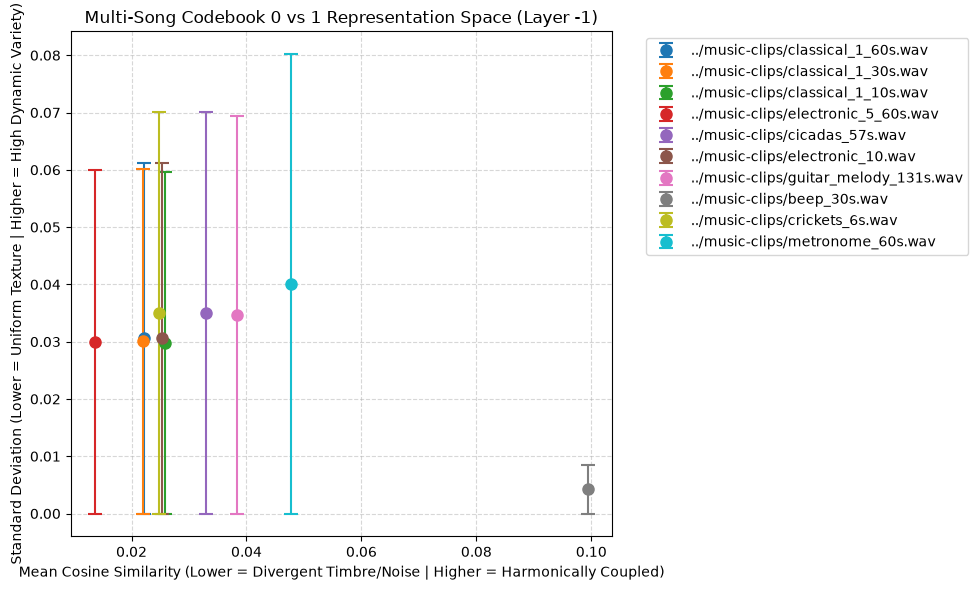

In [ ]:
'''
Plots the mean and standard deviation of cosine similarities between Codebook 0 and 1
for multiple audio clips.
'''
plt.figure(figsize=(10, 6))
for label, (mean, std) in cos_sim_dict.items():
    # Plot point with standard deviation as vertical error bar
    plt.errorbar(mean, std, yerr=std, fmt='o', capsize=5, capthick=1.5, elinewidth=1.5, label=label, markersize=8)

plt.title("Multi-Song Codebook 0 vs 1 Representation Space (Layer -1)")
plt.xlabel("Mean Cosine Similarity (Lower = Divergent Timbre/Noise | Higher = Harmonically Coupled)")
plt.ylabel("Standard Deviation (Lower = Uniform Texture | Higher = High Dynamic Variety)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
'''
WIP: Potential cosine sims between codebooks as they go through transformer layers?
'''
hidden_states_container = {}
def hook_fn(module, input, output):
    hidden_states_container["layer_0_out"] = output[0]

handle = model.decoder.model.decoder.layers[0].register_forward_hook(hook_fn)

Path: ../music-clips/classical_1_30s.wav
Path: ../music-clips/beep_30s.wav


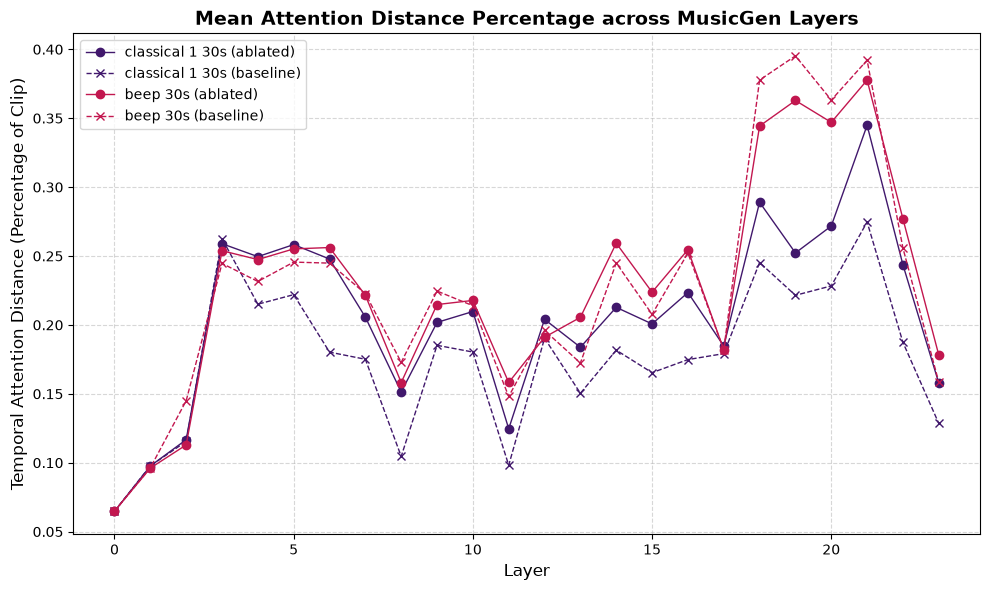

In [ ]:
'''
Investigates zeroing out codebooks 1-3 while keeping Codebook 0 active. Maps results
'''
ablated_mad_dict = {}
baseline_mad_dict = {}

for path in audio_paths:
    print("Path:", path)
    encoder_outputs = model.audio_encoder.encode(
        inputs_dict[path].input_values,
        padding_mask=inputs_dict[path].get("padding_mask")
    )
    # Extract tensor shape: (num_codebooks, seq_len)
    audio_codes = encoder_outputs.audio_codes
    input_ids = audio_codes.squeeze(0).squeeze(0)

    ablated_input_ids = input_ids.clone()

# Create an ablated input array where fine codebooks are replaced with pad/zero tokens
# Zero out fine codebook streams (Keep Codebook 0 active)
    ablated_input_ids[1:, :] = 0

    with torch.no_grad():
        baseline_out = model.decoder(input_ids=input_ids, encoder_hidden_states=None, output_attentions=True)
        ablated_out = model.decoder(input_ids=ablated_input_ids, encoder_hidden_states=None, output_attentions=True)

    # Measure change in Layer X self-attention maps
    # layer = 8
    attn_baseline = baseline_out.attentions
    attn_ablated = ablated_out.attentions

    # attn_diff = torch.norm(attn_baseline - attn_ablated, p="fro")
    # print(f"Attention Frobenius Shift: {attn_diff.item():.4f}")
    ablated_mad = utils.compute_mad_by_layer(attn_ablated, attn_ablated[0].shape[-1])
    baseline_mad = utils.compute_mad_by_layer(attn_baseline, attn_baseline[0].shape[-1])
    ablated_mad_dict[path] = ablated_mad
    baseline_mad_dict[path] = baseline_mad

plt.figure(figsize=(10, 6))

for path, mads in ablated_mad_dict.items():
    random_hex = f"#{random.randint(0, 0xFFFFFF):06x}"
    num_layers = len(ablated_mad_dict.get(path))
    ablated_layer_averages = np.mean(mads, axis=1)
    baseline_layer_averages = np.mean(baseline_mad_dict.get(path), axis=1)
    label = path.replace("../music-clips/", "").replace("_", " ").replace(".wav", "")
    plt.plot(range(num_layers), ablated_layer_averages, color=random_hex, linewidth=1, marker='o', label=f"{label} (ablated)")
    plt.plot(range(num_layers), baseline_layer_averages, color=random_hex, linewidth=1, marker='x', linestyle='--', label=f"{label} (baseline)")

plt.title("Mean Attention Distance Percentage across MusicGen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Layer", fontsize=12)
plt.ylabel("Temporal Attention Distance (Percentage of Clip)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(),
plt.tight_layout()